# Retail Transaction Analysis

This project explores a retail transaction dataset containing
10,000 purchases.

Goals:
- Understand purchasing behavior
- Identify top-selling products
- Analyze revenue patterns
- Explore temporal trends

# Importing libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Reading the data

In [3]:
df=pd.read_csv('Y:/python/data analysis/my datasets/cleaned_cafe_data.csv')

In [4]:
print(df.head())
print(df.info())

  Transaction ID      Item  Quantity  Price Per Unit  Total Spent  \
0    TXN_5728991     Salad       2.0             5.0         10.0   
1    TXN_8249251      Cake       3.0             3.0          9.0   
2    TXN_8842223  Sandwich       5.0             4.0         20.0   
3    TXN_7367474     Juice       5.0             3.0         15.0   
4    TXN_2192787  Sandwich       5.0             4.0         20.0   

   Payment Method  Location Transaction Date  Date missing  
0             NaN       NaN         1/1/2023         False  
1             NaN  In-store         1/1/2023         False  
2  Digital Wallet  In-store         1/1/2023         False  
3  Digital Wallet  Takeaway         1/1/2023         False  
4            Cash  In-store         1/1/2023         False  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction I

In [5]:
df['Item'] = df['Item'].fillna("Unknown")
df['Payment Method'] = df['Payment Method'].fillna("Unknown")
df['Location'] = df['Location'].fillna("Unknown")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    10000 non-null  object 
 1   Item              10000 non-null  object 
 2   Quantity          9977 non-null   float64
 3   Price Per Unit    9994 non-null   float64
 4   Total Spent       9977 non-null   float64
 5   Payment Method    10000 non-null  object 
 6   Location          10000 non-null  object 
 7   Transaction Date  9540 non-null   object 
 8   Date missing      10000 non-null  bool   
dtypes: bool(1), float64(3), object(5)
memory usage: 634.9+ KB
None


In [6]:
df['Item'] = df['Item'].astype('category')
df['Payment Method'] = df['Payment Method'].astype('category')
df['Location'] = df['Location'].astype('category')
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10000 non-null  object        
 1   Item              10000 non-null  category      
 2   Quantity          9977 non-null   float64       
 3   Price Per Unit    9994 non-null   float64       
 4   Total Spent       9977 non-null   float64       
 5   Payment Method    10000 non-null  category      
 6   Location          10000 non-null  category      
 7   Transaction Date  9540 non-null   datetime64[ns]
 8   Date missing      10000 non-null  bool          
dtypes: bool(1), category(3), datetime64[ns](1), float64(3), object(1)
memory usage: 430.5+ KB
None


In [7]:
df.isnull().sum()

Transaction ID        0
Item                  0
Quantity             23
Price Per Unit        6
Total Spent          23
Payment Method        0
Location              0
Transaction Date    460
Date missing          0
dtype: int64

Missing values were handled through a combination of
imputation and cleaning procedures.

# Top items by quantity

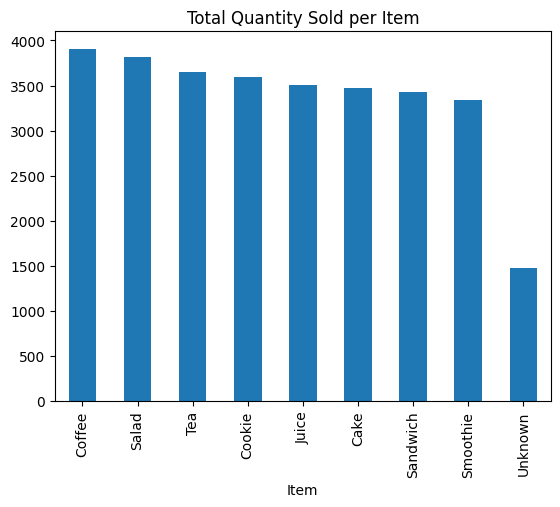

In [8]:
item_sales = (
    df.groupby("Item", observed=True)["Quantity"]
      .sum()
      .sort_values(ascending=False)
)

item_sales.plot(kind="bar")
plt.title("Total Quantity Sold per Item")
plt.show()

Coffee had the highest sales volume, while Smoothie
had the lowest.

# Top Revenue

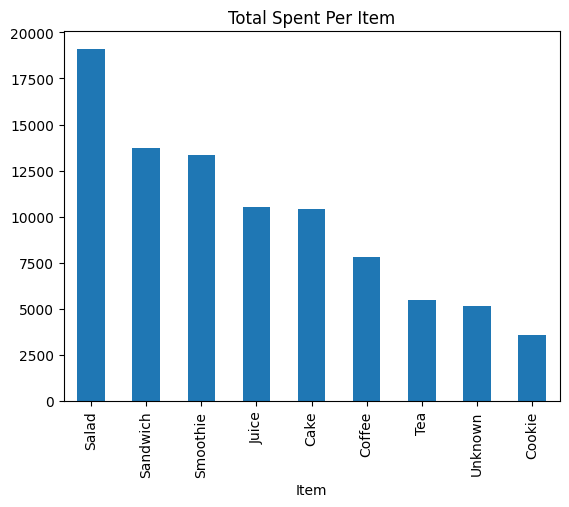

In [10]:
revenue = (
    df.groupby("Item", observed=True)["Total Spent"]
      .sum()
      .sort_values(ascending=False)
)

revenue.plot(kind="bar")
plt.title("Total Spent Per Item")
plt.show()

Although Salad sold fewer units than Coffee,
it generated more revenue.

# Payment Methods

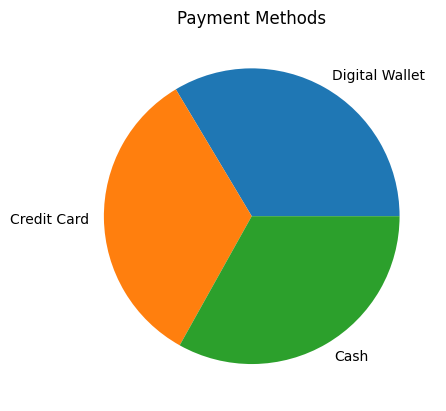

In [16]:
filtered_df = df[df["Payment Method"] != "Unknown"]
filtered_df["Payment Method"].value_counts().plot(kind="pie",ylabel="")
plt.title("Payment Methods")
plt.show()

All methods are almost equal in terms of usage

# Location Analysis

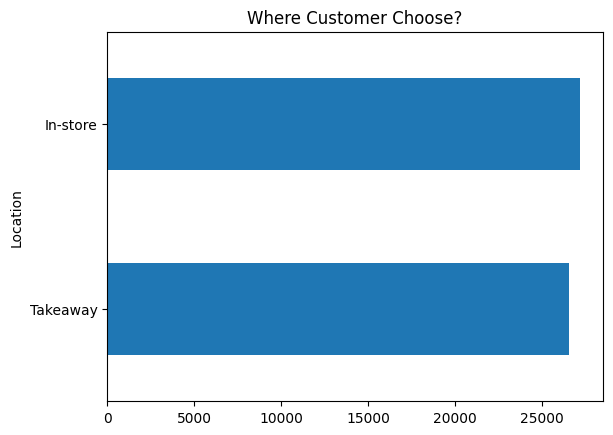

In [18]:
filtered_df = df[df["Location"] != "Unknown"]
location_sales = (
    filtered_df.groupby("Location", observed=True)["Total Spent"]
      .sum()
      .sort_values()
)

location_sales.plot(kind="barh")
plt.title("Where Customer Choose?")
plt.show()

customers prefer In-store purchase slightly more than Takeaway.

# Time Analysis

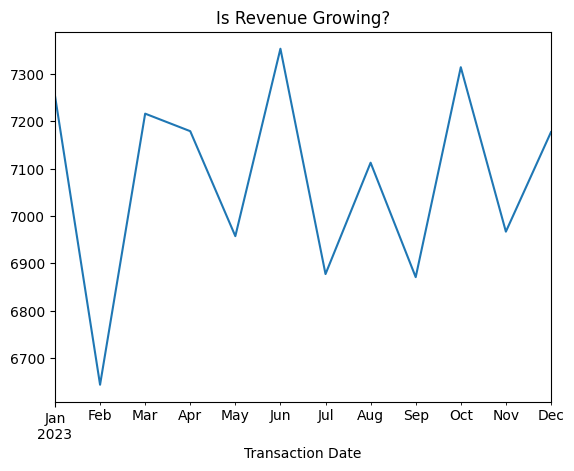

In [21]:
filtered_df = df[df["Transaction Date"] != np.nan]
monthly_sales = (
    filtered_df.set_index("Transaction Date")
      .resample("ME")["Total Spent"]
      .sum()
)

monthly_sales.plot()
plt.title("Is Revenue Growing?")
plt.show()

revenue peaked in June and had dropped in February

# Spending Detribution

(array([ 461.,  518.,  968.,  969.,  238.,  496., 1019.,    0.,  970.,
           0.,  510.,  542.,    0.,  996.,    0.,    0.,    0.,  766.,
         466.,    0.,    0.,    0.,    0.,  789.,    0.,    0.,    0.,
           0.,    0.,  269.]),
 array([ 1. ,  1.8,  2.6,  3.4,  4.2,  5. ,  5.8,  6.6,  7.4,  8.2,  9. ,
         9.8, 10.6, 11.4, 12.2, 13. , 13.8, 14.6, 15.4, 16.2, 17. , 17.8,
        18.6, 19.4, 20.2, 21. , 21.8, 22.6, 23.4, 24.2, 25. ]),
 <BarContainer object of 30 artists>)

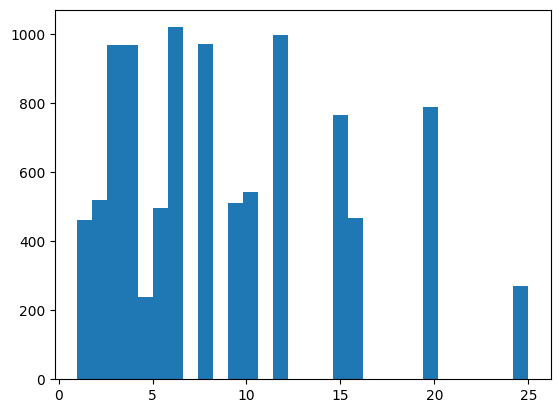

In [22]:
plt.hist(df["Total Spent"], bins=30)

most purchases were under 10$

## Key Findings

- Salad generated the highest revenue.
- Smoothie had fewer transactions but high average value.
- Revenue peaked in June.
- Most transactions were below $10.